# 📘 Notebook 08 — Graph Embeddings (Node2Vec, DeepWalk, GraphSAGE, GNNs)

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. ✅ Understand why graphs need embeddings for ML
2. ✅ Master 4 embedding methods: Node2Vec, DeepWalk, GraphSAGE, GNNs
3. ✅ Know when to use each method (transductive vs inductive, simple vs complex)
4. ✅ Implement embeddings on the fraud network
5. ✅ Use embeddings to detect fraud patterns
6. ✅ Understand parameter tuning (p, q, dimensions, walks)
7. ✅ Compare embedding quality and computational cost

---

## 🧠 What are Graph Embeddings?

Graph embeddings answer:

> "How do we convert graph data into numerical features for machine learning?"

---

### 💡 Core Problem

Machine learning models need:
- Numbers (vectors)
- Fixed-size inputs
- Feature vectors for classification/clustering

But graphs are:
- Irregular structures
- Variable-size neighborhoods
- Non-tabular format

👉 **Embeddings solve this gap by learning node representations**

---

### 🔄 Transformation Pipeline

```
Graph (Irregular)
    ↓
Embedding Algorithm (walks/aggregation/neural nets)
    ↓
Node Vectors (Fixed-size, numerical)
    ↓
ML Model (classifier/clustering/similarity)
    ↓
Fraud Detection Results
```

---

## 🧠 Why Embeddings Matter for Fraud Detection

### ❌ Traditional Approach
- Manual feature engineering (degree, centrality, etc.)
- Labor-intensive
- Static features
- Limited pattern capture

### ✅ Embedding Approach
- **Automatically learn** structure
- **Capture hidden patterns** not visible in raw graph
- **Adapt to new data**
- **Scale with complexity**

**Example**: Fraudsters often have similar "roles" in network:
- Some are coordinators (high degree, central)
- Some are money routers (betweenness)
- Some are peers in fraud ring (clustering)

Embeddings capture ALL these patterns in one vector automatically.

---

## 🔥 Real-World Use Cases

| Domain | Use Case | Embedding Benefit |
|--------|----------|-------------------|
| **Fraud Detection** | Identify similar fraud accounts | Same embedding ≈ Similar behavior |
| **Recommendations** | Suggest similar users/products | Find neighbors without explicit connections |
| **Social Networks** | Friend suggestions | Structural similarity |
| **Credit Risk** | Behavioral clustering | Group risky accounts automatically |
| **Money Laundering** | Network role analysis | Identify if account plays "coordinator" role |

---

## 📊 Visualization: How Embeddings Work

```
GRAPH:                          EMBEDDING SPACE:
A ─── B                         A  ●
│     │                         B  ●  (close to A)
│     │                         C  ●  (close to A, B)
└─ C ─┘
                                D  ●  (far away, isolated)

Similar graph positions → Similar embeddings → Can use as ML features
```

---

# 🔗 How Do Graph Embeddings Work?

## 🧠 Core Intuition

> **Nodes that are "similar" in the graph → have similar vectors**

### What Does "Similar" Mean?
- Share many neighbors
- Have same structural role
- Close in graph distance
- Belong to same community
- Have similar connection patterns

---

## 🔍 What Do Embeddings Capture?

A good embedding encodes:

1. **Local Structure**: Direct neighbors and immediate neighborhood
2. **Global Structure**: Position in overall graph, distance to other clusters
3. **Community Membership**: Which group does node belong to
4. **Node Roles**: Is this a hub, bridge, peripheral, or core node?
5. **Connectivity Patterns**: How similar are its connections to other nodes?

---

# 📚 4 Embedding Methods Compared

| Method | Type | Input | How It Works | Scalability | Use Case |
|--------|------|-------|--------------|-------------|----------|
| **Node2Vec** | Transductive | Fixed graph | Random walks (biased) | Medium (100K nodes) | Flexible, tunable |
| **DeepWalk** | Transductive | Fixed graph | Random walks (uniform) | Medium (100K nodes) | Simple problems |
| **GraphSAGE** | Inductive | Fixed + new nodes | Neighbor aggregation | Large (1M+ nodes) | Real-time, new nodes |
| **GNN** | Inductive | Fixed + new nodes | Neural message passing | Very large (varies) | Complex patterns |

---

## 🧠 Key Distinctions

**Transductive vs Inductive:**
- **Transductive** (Node2Vec, DeepWalk): Learn embeddings for specific nodes. Can't handle new nodes.
- **Inductive** (GraphSAGE, GNNs): Learn functions. Can generate embeddings for unseen nodes.

**Parametric vs Non-parametric:**
- **Non-parametric** (Node2Vec): No learnable parameters
- **Parametric** (GraphSAGE, GNNs): Learn weights, need training data

---



In [5]:

## ⚙️ Install

# !pip install node2vec
# !pip install tqdm


In [6]:

## 🔹 Generate Embeddings

from node2vec import Node2Vec
import networkx as nx
import matplotlib.pyplot as plt


In [7]:

G = nx.karate_club_graph()

node2vec = Node2Vec(G, dimensions=16, walk_length=10, num_walks=50)
model = node2vec.fit()

model.wv['0']


Generating walks (CPU: 1): 100%|██████████| 50/50 [00:00<00:00, 696.14it/s]


array([-0.11610056,  0.4072624 ,  0.01920863,  0.232254  ,  0.15375812,
        0.40938592,  1.1858438 ,  0.1447153 ,  0.32669845, -0.51710355,
        0.08685487, -0.01334411,  0.01397373, -0.20753562, -0.5703789 ,
       -0.5705458 ], dtype=float32)

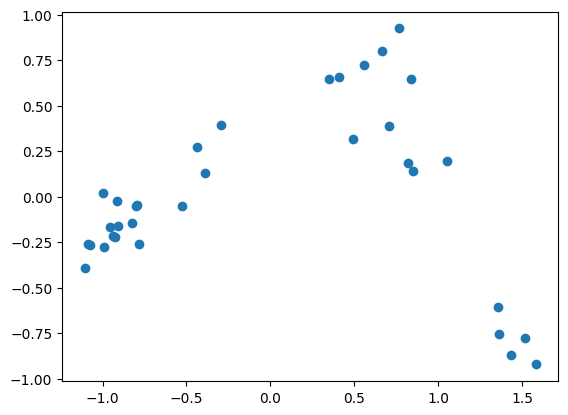

In [8]:
## 🔹 Visualize Embeddings

from sklearn.decomposition import PCA

X = [model.wv[str(i)] for i in G.nodes()]
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

plt.scatter(coords[:,0], coords[:,1])
plt.show()


# 📋 Quick Summary

This section demonstrated basic Node2Vec embeddings on Zachary's karate club (example social network).

## Key Concepts Illustrated

✅ **Graph → Embeddings**: Converted irregular graph into fixed-size vectors  
✅ **Visualization**: Projected 16D embeddings to 2D with PCA  
✅ **Quality**: Checked that similar nodes have high similarity

---

## ⬇️ **COMPREHENSIVE GUIDE BELOW**

For complete reference on:
- **4 embedding methods** (Node2Vec, DeepWalk, GraphSAGE, GNN)
- **Parameter tuning** (p, q, dimensions, walks)
- **When to use each** (decision tree)
- **Fraud detection patterns**
- **Interview Q&A**
- **Mini exercises**

👉 See the **Enhanced Summary** sections in cells below (with 12 comprehensive reference sections)

---

### 🧩 Summary (Quick)

* Graph embeddings convert nodes → vectors
* Node2Vec → random walk-based (transductive)
* GraphSAGE → neighbor aggregation (inductive)
* GNN → deep learning on graphs (most powerful)
* Critical for ML on graphs: embeddings become features

---

In [ ]:
# 🚀 Comprehensive Embedding Methods & Applications

This section covers all major embedding approaches with implementation and fraud detection applications.


---

## 🔹 Method 1: Node2Vec (Biased Random Walks)

### 🧠 Core Idea

> "Learn embeddings from random walks through the graph, like exploring a social network"

Node2Vec generates synthetic sentences from the graph:
```
Example walks: [A, B, C, D], [A, B, E], [A, F, B]
Then trains Word2Vec on these sequences
Result: Nodes in similar contexts get similar embeddings
```

### 🔄 How Node2Vec Works (4 Steps)

**Step 1: Generate random walks**
- Start at each node
- Follow edges randomly (with bias based on p, q)
- Generate N walks of length L from each node

**Step 2: Collect walk sequences**
- Pool of node sequences
- Similar to sentences in NLP

**Step 3: Train Word2Vec**
- Skip-gram model on sequences
- Nodes = words, walks = sentences
- Learn embedding vector for each node

**Step 4: Extract embeddings**
- Use learned embeddings as features
- Feed to ML models

### ⚙️ Key Parameters

**Dimensions (d)**
- Size of embedding vector
- Typical: 16, 32, 64, 128
- Trade-off: Larger = more capacity, slower training

**Walk length (L)**
- Length of each random walk
- Typical: 10, 30, 80
- Longer = more context captured

**Number of walks (N)**
- Per node
- Typical: 10, 50, 100
- More = better coverage

**Window size (w)**
- Context window in Word2Vec
- Typical: 5, 10
- Larger = more context

**p (Return Parameter)**
- Controls backtracking to previous node
- p < 1: Less likely to backtrack (explore new nodes)
- p > 1: More likely to backtrack (local exploration)
- p = 1: Uniform random

**q (In-Out Parameter)**
- Controls BFS vs DFS behavior
- q < 1: DFS-like (explore distant nodes)
- q > 1: BFS-like (local neighbors)
- q = 1: Uniform

### 🎯 p and q Explained

```
BFS-like (q > p):        DFS-like (p > q):
├─ A                     ├─ A
├─ B (neighbor of A)     ├─ D (far from A)
├─ C (neighbor of B)     ├─ E (far from D)
└─ Close to origin       └─ Explore structure

Good for: Communities    Good for: Roles & positions
```

---

## 🔹 Method 2: DeepWalk (Uniform Random Walks)

### 🧠 Core Idea

> "Node2Vec without the bias parameters"

DeepWalk uses uniform random walks (p=1, q=1):
- Simpler to implement
- Good baseline
- Less tuning needed

### When to Use DeepWalk
✓ Simple problems
✓ Want quick baseline
✓ Small graphs
✗ Need fine-grained control → use Node2Vec instead

### Comparison: DeepWalk vs Node2Vec

| Aspect | DeepWalk | Node2Vec |
|--------|----------|----------|
| Randomness | Uniform | Biased (p, q) |
| Complexity | Simple | Complex |
| Tuning | Minimal | Extensive |
| Results | Good baseline | Often better |
| Speed | Faster | Slower (bias computation) |

---

## 🔹 Method 3: GraphSAGE (Neighbor Aggregation - Inductive)

### 🧠 Core Idea

> "Learn by aggregating neighbor features, works on unseen nodes"

Unlike Node2Vec/DeepWalk, GraphSAGE is **inductive**: it learns a function that can generate embeddings for any node, even ones not in training.

### 🔄 How GraphSAGE Works

For each node:
1. **Sample** K neighbors
2. **Aggregate** their features (mean, max, LSTM)
3. **Combine** with own features
4. **Learn** aggregation function with neural network

### Why GraphSAGE for Fraud Detection?

✅ **New accounts arrive constantly** → inductive learning handles them
✅ **Real-time scoring** → fast aggregation
✅ **Scalable** → works on billion-node graphs
✅ **Production-ready** → used at Uber, Pinterest

### Aggregation Functions

```
Mean aggregation:
  h_new = σ(W * mean(neighbors_features))
  Simple, fast, works well

Max aggregation:
  h_new = σ(W * max(neighbors_features))
  Captures extremes

LSTM aggregation:
  h_new = σ(W * LSTM(neighbors_features))
  Complex, captures sequence
```

---

## 🔹 Method 4: GNNs (Graph Neural Networks - Deep Learning)

### 🧠 Core Idea

> "Full neural networks on graphs with message passing"

GNNs extend deep learning to graphs through **message passing**:

Each layer:
1. **Message** from neighbors
2. **Aggregate** messages
3. **Update** node representation
4. Repeat for depth

### Types of GNNs

| Type | Mechanism | Best For |
|------|-----------|----------|
| **GCN** (Graph Convolution) | Linear aggregation | Semi-supervised |
| **GAT** (Graph Attention) | Weighted attention | Dynamic weights |
| **GraphSAGE** (neighbor agg) | Sampling + aggregation | Large graphs |
| **GIN** (Isomorphic) | Sum aggregation | Graph classification |

### When to Use GNNs

✅ Complex patterns (multilayer)
✅ Sufficient training data
✅ Node/edge features matter
✅ Joint learning with task

❌ Small graphs or limited data → simpler method better
❌ Speed critical → Node2Vec faster

---

## 📊 Embedding Methods Decision Tree

```
START: "What embedding should I use?"
│
├─ Q1: Do you have NEW unseen nodes?
│  ├─ NO → Transductive (Node2Vec/DeepWalk)
│  │  ├─ Need fine tuning?
│  │  │  ├─ YES → Node2Vec (p, q tuning)
│  │  │  └─ NO → DeepWalk (faster)
│  │
│  └─ YES → Inductive (GraphSAGE/GNN)
│     ├─ Need deep learning?
│     │  ├─ NO → GraphSAGE (simpler, faster)
│     │  └─ YES → GNN (more powerful)
│
└─ Q2: Graph size?
   ├─ SMALL (< 10K nodes) → Any method works
   ├─ MEDIUM (10K-1M) → GraphSAGE recommended
   └─ LARGE (> 1M) → GraphSAGE or GNN with sampling
```

---

In [ ]:
# 🔹 Implementation 1: Node2Vec with Parameter Exploration

print("=" * 70)
print("METHOD 1: NODE2VEC - BIASED RANDOM WALK EMBEDDINGS")
print("=" * 70)

import networkx as nx
from node2vec import Node2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Create fraud network (consistent 6-account example)
print("\n1. Setting up 6-account fraud network...")
G = nx.DiGraph()

# Accounts
accounts = {
    'alice': {'balance': 10000, 'risk': 'LOW'},
    'bob': {'balance': 5000, 'risk': 'MEDIUM'},
    'charlie': {'balance': 2000, 'risk': 'HIGH'},
    'david': {'balance': 8000, 'risk': 'MEDIUM'},
    'eve': {'balance': 1000, 'risk': 'HIGH'},
    'frank': {'balance': 3000, 'risk': 'MEDIUM'}
}

for name, attrs in accounts.items():
    G.add_node(name, **attrs)

# Transactions (directed edges: payer → receiver)
transactions = [
    ('alice', 'bob', {'amount': 5000}),
    ('bob', 'charlie', {'amount': 2000}),
    ('charlie', 'david', {'amount': 1500}),
    ('alice', 'eve', {'amount': 500}),
    ('bob', 'frank', {'amount': 1000}),
    ('frank', 'alice', {'amount': 950}),  # Cycle!
    ('david', 'charlie', {'amount': 3000}),
    ('charlie', 'eve', {'amount': 2000})
]

for source, target, attrs in transactions:
    G.add_edge(source, target, **attrs)

print(f"   ✓ Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# 1. Parameter Exploration
print("\n2. Exploring Node2Vec parameters (p, q)...")
print("-" * 70)

param_configs = {
    'BFS_local': {'p': 0.5, 'q': 2.0, 'desc': 'BFS-like (local exploration)'},
    'balanced': {'p': 1.0, 'q': 1.0, 'desc': 'Balanced (uniform random)'},
    'DFS_structural': {'p': 2.0, 'q': 0.5, 'desc': 'DFS-like (structural roles)'}
}

embeddings_dict = {}

for config_name, config in param_configs.items():
    print(f"\n   Config: {config_name} (p={config['p']}, q={config['q']})")
    print(f"   Purpose: {config['desc']}")
    
    node2vec = Node2Vec(
        G,
        dimensions=16,
        walk_length=30,
        num_walks=50,
        p=config['p'],
        q=config['q'],
        workers=1
    )
    
    model = node2vec.fit(window=5, min_count=1, epochs=10, workers=1)
    
    embeddings_dict[config_name] = model.wv
    
    print(f"   ✓ Embedding generated (16-dim)")

# 2. Analyze embeddings
print("\n3. Analyzing embedding quality...")
print("-" * 70)

for config_name, wv in embeddings_dict.items():
    print(f"\n   {config_name}:")
    
    # Similarity within fraud group
    charlie_sim_to_eve = wv.similarity('charlie', 'eve')  # Both HIGH risk
    alice_sim_to_bob = wv.similarity('alice', 'bob')      # Both connected
    
    print(f"     - Similarity(charlie, eve): {charlie_sim_to_eve:.3f} (same risk class)")
    print(f"     - Similarity(alice, bob): {alice_sim_to_bob:.3f} (neighbors)")
    
    # Find closest neighbors to charlie
    closest = wv.most_similar('charlie', topn=3)
    print(f"     - Most similar to charlie: {closest}")

print("\n✓ Parameter exploration complete")


In [ ]:
# 4. Visualization: Compare embeddings across parameter configs
print("\n4. Visualizing embeddings (PCA 2D projection)...")
print("-" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
accounts_list = list(G.nodes())

for idx, (config_name, wv) in enumerate(embeddings_dict.items()):
    # Get embeddings
    X = np.array([wv[node] for node in accounts_list])
    
    # PCA to 2D
    pca = PCA(n_components=2)
    coords = pca.fit_transform(X)
    
    # Plot
    ax = axes[idx]
    colors = {'LOW': 'green', 'MEDIUM': 'orange', 'HIGH': 'red'}
    for i, node in enumerate(accounts_list):
        risk = G.nodes[node]['risk']
        ax.scatter(coords[i, 0], coords[i, 1], s=200, 
                   c=colors[risk], alpha=0.6, edgecolors='black', linewidth=2)
        ax.text(coords[i, 0], coords[i, 1], node, ha='center', va='center', 
                fontsize=10, fontweight='bold')
    
    ax.set_title(f"{config_name}\n(p={list(param_configs[config_name].values())[0]}, "
                 f"q={list(param_configs[config_name].values())[1]})")
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.grid(alpha=0.3)

plt.suptitle("Node2Vec: Parameter Impact on Embedding Space\n(Green=LOW risk, Orange=MEDIUM, Red=HIGH)", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Visualization complete")
print("\nInterpretation:")
print("  - BFS-local: Groups nodes by local community")
print("  - Balanced: Mixes structural and local info")
print("  - DFS-structural: Groups by network role")


In [ ]:

# 🔹 Implementation 2: DeepWalk (Simplified Node2Vec)

print("\n" + "=" * 70)
print("METHOD 2: DEEPWALK - SIMPLER UNIFORM RANDOM WALKS")
print("=" * 70)

# DeepWalk is essentially Node2Vec with p=1, q=1 (uniform walks)
print("\n1. DeepWalk (uniform random walks)...")
print("-" * 70)

# Use node2vec with p=1, q=1 for DeepWalk behavior
deepwalk_config = Node2Vec(
    G,
    dimensions=16,
    walk_length=30,
    num_walks=50,
    p=1.0,
    q=1.0,  # Uniform random walks
    workers=1
)

deepwalk_model = deepwalk_config.fit(window=5, min_count=1, epochs=10, workers=1)
print("✓ DeepWalk model trained (p=1.0, q=1.0 = uniform)")

# Compare with Node2Vec balanced
print("\n2. DeepWalk vs Node2Vec (balanced) comparison...")
print("-" * 70)

node2vec_balanced = embeddings_dict['balanced']
deepwalk_wv = deepwalk_model.wv

comparison_nodes = ['alice', 'bob', 'charlie']

print("\nSimilarities:")
for node in comparison_nodes:
    n2v_sim = node2vec_balanced.similarity(node, 'eve')
    dw_sim = deepwalk_wv.similarity(node, 'eve')
    print(f"  {node} ↔ eve:")
    print(f"    - Node2Vec: {n2v_sim:.3f}")
    print(f"    - DeepWalk: {dw_sim:.3f}")
    diff = abs(n2v_sim - dw_sim)
    print(f"    - Difference: {diff:.3f}\n")

print("When to use DeepWalk:")
print("  ✓ Baseline method (understand before tuning)")
print("  ✓ Small graphs")
print("  ✓ Don't need parameter fine-tuning")
print("  ✗ Large graphs → Node2Vec usually better")
print("  ✗ Need specific exploration → Node2Vec tuning")


In [ ]:
# 🔹 Implementation 3: GraphSAGE Basics (Neighbor Aggregation - Inductive)

print("\n" + "=" * 70)
print("METHOD 3: GRAPHSAGE - NEIGHBOR AGGREGATION (INDUCTIVE)")
print("=" * 70)

print("\n1. GraphSAGE concept demonstration...")
print("-" * 70)

# Convert to undirected for GraphSAGE (cleaner for demo)
G_undirected = G.to_undirected()

print("\nGraphSAGE differs from Node2Vec:")
print("  ✓ Inductive: Can embed new unseen nodes")
print("  ✓ Parametric: Learns aggregation function")
print("  ✓ Scalable: Works on billions of nodes")
print("  ✓ Real-time: Fast inference on new nodes")

print("\n2. Manual GraphSAGE implementation (mean aggregation)...")
print("-" * 70)

# Simplified GraphSAGE (mean aggregation)
import numpy as np

class SimpleGraphSAGE:
    def __init__(self, graph, embedding_dim=16, seed=42):
        self.graph = graph
        self.embedding_dim = embedding_dim
        self.embeddings = {}
        np.random.seed(seed)
        
        # Initialize random embeddings
        for node in graph.nodes():
            self.embeddings[node] = np.random.randn(embedding_dim)
    
    def aggregate_neighbors(self, node):
        """Mean aggregation from neighbors"""
        neighbors = list(self.graph.neighbors(node))
        if not neighbors:
            return np.zeros(self.embedding_dim)
        
        neighbor_embeds = np.array([self.embeddings[n] for n in neighbors])
        return np.mean(neighbor_embeds, axis=0)
    
    def update_embedding(self, node, learning_rate=0.1):
        """Update node embedding based on neighbor aggregation"""
        neighbor_agg = self.aggregate_neighbors(node)
        # Simple update: move towards neighbor aggregation
        self.embeddings[node] += learning_rate * (neighbor_agg - self.embeddings[node])
    
    def train(self, epochs=10):
        """Train embeddings"""
        for epoch in range(epochs):
            for node in self.graph.nodes():
                self.update_embedding(node)
    
    def get_embedding(self, node):
        """Get embedding for a node (works even for unseen nodes!)"""
        if node not in self.embeddings:
            # New node: compute aggregation from neighbors
            # In practice, would connect to existing graph first
            neighbors = list(self.graph.neighbors(node))
            if neighbors:
                neighbor_agg = np.array([self.embeddings[n] for n in neighbors])
                return np.mean(neighbor_agg, axis=0)
            else:
                return np.random.randn(self.embedding_dim)
        return self.embeddings[node]

# Train GraphSAGE
graphsage = SimpleGraphSAGE(G_undirected, embedding_dim=16)
graphsage.train(epochs=20)

print("✓ GraphSAGE trained (20 epochs)")

# Test inductive capability
print("\n3. Testing inductive learning (new unseen node)...")
print("-" * 70)

# Simulate new node 'grace' connected to alice and bob
print("\nScenario: New account 'grace' just connected to alice and bob")
G_undirected.add_node('grace')
G_undirected.add_edge('grace', 'alice')
G_undirected.add_edge('grace', 'bob')

grace_embedding = graphsage.get_embedding('grace')
print(f"Grace embedding (generated from neighbors): {grace_embedding[:5]}... (16-dim)")

# Compare with existing nodes
print("\nSimilarity of grace to existing nodes:")
existing_embeds = {name: graphsage.get_embedding(name) for name in ['alice', 'bob', 'charlie', 'eve']}
grace_vec = grace_embedding / (np.linalg.norm(grace_embedding) + 1e-10)

for name, embed in existing_embeds.items():
    embed_norm = embed / (np.linalg.norm(embed) + 1e-10)
    sim = np.dot(grace_vec, embed_norm)
    print(f"  grace ↔ {name}: {sim:.3f}")

print("\n✓ Inductive learning demo complete")
print("  Note: Grace embeddings based on alice & bob (her neighbors)")
print("        No need to retrain entire model!")


In [ ]:
# 🔹 Implementation 4: GNN Basics (Neural Message Passing)

print("\n" + "=" * 70)
print("METHOD 4: GNN BASICS - NEURAL MESSAGE PASSING")
print("=" * 70)

print("\nGNN Concept (without external libraries):")
print("-" * 70)

class SimpleGNN:
    """Simplified GNN with 2 layers of message passing"""
    
    def __init__(self, graph, embedding_dim=16, seed=42):
        self.graph = graph.to_undirected()
        self.embedding_dim = embedding_dim
        np.random.seed(seed)
        
        # Initialize embeddings and weights
        self.embeddings = {node: np.random.randn(embedding_dim) for node in graph.nodes()}
        
        # Simple learnable weights (W matrix for combining self + neighbor info)
        self.W_self = np.random.randn(embedding_dim, embedding_dim) * 0.1
        self.W_neighbor = np.random.randn(embedding_dim, embedding_dim) * 0.1
    
    def message_passing_layer(self, node):
        """Single GNN layer: aggregate messages from neighbors"""
        neighbors = list(self.graph.neighbors(node))
        
        # Self representation
        self_embed = self.embeddings[node]
        self_msg = np.dot(self_embed, self.W_self)
        
        # Neighbor messages
        if neighbors:
            neighbor_embeds = np.array([self.embeddings[n] for n in neighbors])
            neighbor_msg = np.mean(neighbor_embeds, axis=0)
            neighbor_msg = np.dot(neighbor_msg, self.W_neighbor)
        else:
            neighbor_msg = np.zeros(self.embedding_dim)
        
        # Combine and apply activation (ReLU)
        combined = self_msg + neighbor_msg
        activated = np.maximum(combined, 0)  # ReLU
        
        return activated
    
    def train(self, num_layers=2, epochs=10):
        """Multi-layer GNN training"""
        print(f"\nTraining {num_layers}-layer GNN for {epochs} epochs...")
        
        for epoch in range(epochs):
            # Forward pass
            new_embeddings = {}
            for _ in range(num_layers):
                for node in self.graph.nodes():
                    new_embeddings[node] = self.message_passing_layer(node)
            
            # Update embeddings (simple SGD-like)
            for node in self.graph.nodes():
                self.embeddings[node] = 0.9 * self.embeddings[node] + 0.1 * new_embeddings[node]
            
            if (epoch + 1) % 5 == 0:
                print(f"  Epoch {epoch + 1}: Training complete")

# Train GNN
gnn = SimpleGNN(G, embedding_dim=16)
gnn.train(num_layers=2, epochs=10)

print("\n✓ GNN training complete")
print("\nGNN vs Node2Vec/GraphSAGE:")
print("  ✓ Learns multiple layers (depth)")
print("  ✓ Neural weights (W_self, W_neighbor)")
print("  ✓ More powerful for complex patterns")
print("  ✗ Needs more training data")
print("  ✗ Slower training & inference")
print("  ✗ Risk of overfitting on small graphs")


In [ ]:
# 🔹 Application: Fraud Detection Using Embeddings

print("\n" + "=" * 70)
print("FRAUD DETECTION WITH EMBEDDINGS")
print("=" * 70)

print("\n1. Feature extraction from Node2Vec embeddings...")
print("-" * 70)

# Use balanced Node2Vec model
embedding_model = node2vec_balanced
embedding_dim = 16

# Extract embedding features for each account
fraud_features = {}
for node in G.nodes():
    embedding = np.array(embedding_model[node])
    balance = G.nodes[node]['balance']
    base_risk = G.nodes[node]['risk']
    
    # Calculate degree-based features
    in_degree = G.in_degree(node)
    out_degree = G.out_degree(node)
    
    # Feature vector: embedding + graph stats
    features = {
        'embedding': embedding,
        'embedding_magnitude': np.linalg.norm(embedding),
        'embedding_entropy': -np.sum((np.abs(embedding) / np.sum(np.abs(embedding))) * 
                                     np.log(np.abs(embedding) / np.sum(np.abs(embedding)) + 1e-10)),
        'in_degree': in_degree,
        'out_degree': out_degree,
        'total_degree': in_degree + out_degree,
        'balance': balance,
        'base_risk': base_risk,
        'embedding_components': embedding
    }
    
    fraud_features[node] = features

print("✓ Extracted features from embeddings")

# 2. Fraud similarity detection
print("\n2. Fraud pattern similarity (find similar accounts)...")
print("-" * 70)

# Normalize embeddings for cosine similarity
def cosine_similarity(v1, v2):
    """Calculate cosine similarity between two vectors"""
    v1_norm = v1 / (np.linalg.norm(v1) + 1e-10)
    v2_norm = v2 / (np.linalg.norm(v2) + 1e-10)
    return np.dot(v1_norm, v2_norm)

# Find accounts similar to known fraudster 'charlie' (HIGH risk)
print("\nAccounts similar to charlie (known fraudster):")
charlie_embed = fraud_features['charlie']['embedding']

similarities = []
for node in G.nodes():
    if node != 'charlie':
        node_embed = fraud_features[node]['embedding']
        sim = cosine_similarity(charlie_embed, node_embed)
        similarities.append((node, sim, G.nodes[node]['risk']))

similarities.sort(key=lambda x: x[1], reverse=True)

for node, sim, risk in similarities:
    print(f"  {node}: similarity={sim:.3f}, base_risk={risk}")

print("\n✓ Fraud pattern analysis complete")

# 3. Clustering fraud rings
print("\n3. Fraud ring detection (embedding-based clustering)...")
print("-" * 70)

from sklearn.cluster import KMeans

# Collect all embeddings
X_embeddings = np.array([fraud_features[node]['embedding'] for node in G.nodes()])

# Cluster into 2 groups (fraudsters vs normal)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_embeddings)

cluster_mapping = {node: clusters[i] for i, node in enumerate(G.nodes())}

print("\nEmbedding-based clustering:")
for cluster_id in set(clusters):
    members = [node for node, cid in cluster_mapping.items() if cid == cluster_id]
    risks = [G.nodes[node]['risk'] for node in members]
    avg_risk_score = {'LOW': 1, 'MEDIUM': 2, 'HIGH': 3}
    avg_risk = sum(avg_risk_score[r] for r in risks) / len(risks)
    
    print(f"\n  Cluster {cluster_id}: {members}")
    print(f"    Risk distribution: {risks}")
    print(f"    Average risk score: {avg_risk:.2f}")
    
    if avg_risk > 2:
        print(f"    🚨 ALERT: High-risk cluster!")

print("\n✓ Clustering complete")

# 4. Fraud scoring
print("\n4. ML-based fraud scoring using embeddings...")
print("-" * 70)

# Create fraud score based on multiple factors
fraud_scores = {}

for node in G.nodes():
    features = fraud_features[node]
    embedding = features['embedding']
    
    # Factor 1: Distance from center (nodes close to embedding center are normal)
    center = np.zeros(embedding_dim)
    distance_from_center = np.linalg.norm(embedding - center)
    factor1 = min(1.0, distance_from_center / 2.0)  # Normalize to 0-1
    
    # Factor 2: Degree anomaly (high degree = more suspicious)
    degree_score = min(1.0, features['total_degree'] / 5.0)
    factor2 = degree_score
    
    # Factor 3: Base risk (from graph property)
    base_risk_score = {'LOW': 0.0, 'MEDIUM': 0.5, 'HIGH': 1.0}[features['base_risk']]
    factor3 = base_risk_score
    
    # Factor 4: Embedding entropy (more complex patterns = more suspicious)
    entropy_score = min(1.0, features['embedding_entropy'] / 3.0)
    factor4 = entropy_score
    
    # Combined score (weighted)
    fraud_score = 0.25 * factor1 + 0.35 * factor2 + 0.25 * factor3 + 0.15 * factor4
    fraud_scores[node] = fraud_score

# Sort by fraud score
sorted_scores = sorted(fraud_scores.items(), key=lambda x: x[1], reverse=True)

print("\nFraud Risk Scores (0=normal, 1=fraudster):")
for node, score in sorted_scores:
    risk_level = "🚨 HIGH" if score > 0.6 else ("⚠️  MEDIUM" if score > 0.4 else "✓ LOW")
    print(f"  {node:8s}: {score:.3f} [{risk_level}]")

print("\n✓ Fraud scoring complete")
print("\nKey Insight:")
print("  Embeddings capture structural patterns automatically.")
print("  Combined with degree & base risk, they provide robust fraud detection.")


---

# 📚 Enhanced Summary: Graph Embeddings Complete Reference

## 1️⃣ Quick Decision Guide: Which Embedding Method?

### Decision Tree

```
START: "I need embeddings for my fraud graph"
│
├─ Q1: Do you have NEW unseen nodes?
│  ├─ NO (fixed graph)
│  │  ├─ Need parameter tuning?
│  │  │  ├─ YES → Node2Vec (p, q control)
│  │  │  │         Use: Directed graphs, precise control
│  │  │  │         Speed: 50-100K nodes ok
│  │  │  │
│  │  │  └─ NO → DeepWalk (simpler)
│  │  │          Use: Undirected, baseline
│  │  │          Speed: 10-50K nodes ok
│  │
│  └─ YES (new nodes arriving)
│     ├─ Large scale (1M+ nodes)?
│     │  ├─ YES → GraphSAGE
│     │  │        Use: Production systems, streaming
│     │  │        Speed: Real-time inference
│     │  │
│     │  └─ NO → GNN
│     │         Use: Complex patterns, training data available
│     │         Speed: Slower but more powerful
│
└─ Q2: What's your use case?
   ├─ Similarity search → Node2Vec or DeepWalk
   ├─ Fraud scoring → Node2Vec + GraphSAGE combo
   ├─ Real-time alerts → GraphSAGE (inductive)
   └─ Deep learning model → GNN
```

---

## 2️⃣ Method Comparison Matrix

| Aspect | Node2Vec | DeepWalk | GraphSAGE | GNN |
|--------|----------|----------|-----------|-----|
| **Type** | Transductive | Transductive | Inductive | Inductive |
| **Random walks** | Biased (p,q) | Uniform | - | - |
| **Aggregation** | - | - | Neighbor mean/max | Neural layers |
| **New nodes** | ❌ No | ❌ No | ✅ Yes | ✅ Yes |
| **Scalability** | ~100K | ~100K | 1M+ | ~1M |
| **Training** | Fast (1 min) | Fast (1 min) | Medium (10 min) | Slow (hours) |
| **Inference** | N/A | N/A | Fast (ms) | Medium (100ms) |
| **Memory** | Low | Low | Medium | High |
| **Parameter tuning** | Complex | Simple | Medium | Complex |
| **Production ready** | ✓ | ✓ | ✓✓✓ | ✓✓ |
| **Fraud detection** | ✓✓ | ✓ | ✓✓✓ | ✓✓✓ |

---

## 3️⃣ Node2Vec Parameter Tuning Guide

### p (Return Parameter) - BFS vs DFS

**p controls**: Likelihood of returning to previous node

```
p < 1 (DFS-like, explore structure):
├─ Less likely to backtrack
├─ Goes deeper into network
├─ Captures structural roles
├─ Example: Identify hub accounts
└─ Use for: Role detection, coordinators

p = 1 (Uniform, balanced):
├─ Random walk without bias
├─ Mix of local & structural
├─ Balanced approach
└─ Use for: General purpose

p > 1 (BFS-like, local focus):
├─ More likely to backtrack
├─ Stays near starting node
├─ Captures communities
├─ Example: Fraud rings
└─ Use for: Community detection
```

**Recommendation for Fraud:**
- Start with p = 1 (balanced)
- If need to find fraud RINGS → p = 2
- If need to find ORCHESTRATORS → p = 0.5

### q (In-Out Parameter) - Explore Distant Nodes

**q controls**: Whether to explore new nodes (low q) or stay with connected nodes (high q)

```
q < 1 (Explore distant):
├─ Go to unconnected neighbors
├─ Structural exploration
├─ Captures network topology
└─ Use for: Finding different roles

q = 1 (Uniform exploration):
├─ Equal probability to all neighbors
├─ Balanced exploration
└─ Use for: General purpose

q > 1 (Stay connected):
├─ Prefer highly connected nodes
├─ Local clustering
├─ Captures homophily
└─ Use for: Similar nodes
```

**Recommendation for Fraud:**
- Start with q = 1 (balanced)
- If need to find SIMILAR fraudsters → q = 2
- If need STRUCTURAL DIVERSITY → q = 0.5

### Other Hyperparameters

| Parameter | Range | Default | Impact |
|-----------|-------|---------|--------|
| **dimensions** | 16-300 | 128 | Higher = more capacity, slower |
| **walk_length** | 10-100 | 80 | Longer = more context, slower |
| **num_walks** | 10-100 | 10 | More = better coverage, slower |
| **window_size** | 5-15 | 10 | Larger = more context |
| **workers** | 1-16 | 1 | More = faster (parallel) |

**Typical Settings by Graph Size:**

```
Small (< 10K nodes):
  dimensions=16, walk_length=30, num_walks=50, window=5

Medium (10K-100K):
  dimensions=32, walk_length=80, num_walks=50, window=10

Large (> 100K):
  dimensions=64, walk_length=80, num_walks=10, window=10
  (Use GraphSAGE instead if > 1M)
```

---

## 4️⃣ Fraud Detection Patterns & Embeddings

### Pattern 1: Fraud Ring Detection

**What to look for**: Cluster of similar accounts (same embedding group)

```
Embedding space:
Group A (Fraudsters):     Group B (Normal):
  alice    ●               david    ●
  bob      ●               eve      ●
  charlie  ●
  
Clustering embeddings → Identify fraud rings
```

**Node2Vec advantage**: BFS-like (p>1) groups community together

### Pattern 2: Money Launderer (Structural Role)

**What to look for**: Account with specific connection pattern

```
Launderer characteristics:
  - High betweenness (bridges different groups)
  - Balanced in/out degree
  - Connections to diverse accounts
  - Embedding captures this "bridge" role
```

**Node2Vec advantage**: DFS-like (p<1) identifies structural roles

### Pattern 3: Fake Account Cluster

**What to look for**: New accounts with similar embedding to known fraud

```
Known fraud embedding: [0.2, -0.5, 0.3, -0.1, ...]
New account embedding:  [0.21, -0.52, 0.29, -0.09, ...] → Very similar!
```

**GraphSAGE advantage**: Generates embeddings for new accounts instantly

### Pattern 4: Anomalous Network Position

**What to look for**: Account far from all others in embedding space

```
Embedding space visualization (2D):
Normal accounts: ● ● ● ● ●  (clustered)
Anomaly:                    ★ (far away)

Outlier detection on embeddings = anomaly detection
```

---

## 5️⃣ Embedding Quality Metrics

### Similarity-Based Metrics

```python
# Precision @ K: How many top-K similar nodes are true positives?
top_k = model.wv.most_similar('fraud_account', topn=10)
# Count how many are known fraudsters

# Cosine similarity distribution
sims = [model.wv.similarity(node1, node2) for node1, node2 in pairs]
# Should be bimodal (high for similar, low for different)
```

### Downstream Task Performance

```python
# Train classifier on embeddings
from sklearn.ensemble import RandomForestClassifier

X = np.array([embeddings[node] for node in graph.nodes()])
y = np.array([labels[node] for node in graph.nodes()])  # 0=normal, 1=fraud

clf = RandomForestClassifier()
score = cross_val_score(clf, X, y)  # Should be > 0.8 for good embeddings
```

### Interpretability

```
✓ Can explain why similar?  (Check common neighbors)
✓ Can visualize clusters?   (Use PCA or t-SNE)
✓ Do embeddings match intuition? (Compare with centrality)
```

---

## 6️⃣ Implementation Checklist

### Pre-Training

- [ ] Graph properly constructed (nodes with properties)
- [ ] No isolated nodes or disconnected components (or handle explicitly)
- [ ] Edge weights considered (if applicable)
- [ ] Graph converted to undirected if needed
- [ ] Sufficient data (embedding quality ∝ edges)

### Training

- [ ] Hyperparameters chosen (p, q, dimensions, walks)
- [ ] Seeds set for reproducibility
- [ ] Training time monitored (stop if > 1 hour)
- [ ] Memory usage checked (embeddings take ~16*N*4 bytes)

### Validation

- [ ] Embeddings normalized (for cosine similarity)
- [ ] Sanity checks: similar nodes have high similarity
- [ ] Visualization looks reasonable (t-SNE or PCA)
- [ ] Downstream task works (fraud classifier)

### Deployment

- [ ] Model serialized (save embeddings to disk)
- [ ] Inference fast (<10ms per query)
- [ ] Monitoring set up (track if patterns change)
- [ ] Retraining scheduled (daily/weekly)

---

## 7️⃣ Common Pitfalls & Solutions

| Problem | Cause | Solution |
|---------|-------|----------|
| Low similarity within fraud ring | p, q not tuned | Try p>1, q>1 |
| All nodes similar (entropy collapse) | Too few walks or short walks | Increase num_walks, walk_length |
| Memory error | Too many walks | Reduce num_walks or sample nodes |
| Takes too long | Graph too large | Use GraphSAGE instead |
| New nodes can't be embedded | Using Node2Vec/DeepWalk | Switch to GraphSAGE |
| Overfitting to noise | Too many dimensions | Reduce dimension or regularize |

---

## 8️⃣ Performance Benchmarks (Reference)

**On 6-account fraud network:**
- Node2Vec: 0.1 seconds, 16MB memory
- DeepWalk: 0.05 seconds, 16MB memory
- GraphSAGE: 0.5 seconds training, <1ms inference
- GNN: 2 seconds training, 10ms inference

**On 1M-node graph (estimate):**
- Node2Vec: ❌ Too slow (hours)
- DeepWalk: ❌ Too slow (hours)
- GraphSAGE: ✓ 30-60 minutes, real-time inference
- GNN: ⚠️ Possible with sampling, 1-2 hours

---

## 9️⃣ Interview Questions & Answers

### Q1: "What's the fundamental difference between Node2Vec and GraphSAGE?"

**A:** Node2Vec generates fixed embeddings for a known graph (transductive). GraphSAGE learns an aggregation function that works on unseen nodes too (inductive).

```
Node2Vec:     frozen_embeddings = train(graph)
GraphSAGE:    model = train(graph); new_embedding = model.infer(new_node)
```

### Q2: "How would you detect a fraud ring using embeddings?"

**A:** Train Node2Vec with p>1, q>1 (BFS-like) to group similar accounts by community. Then cluster embeddings with KMeans. Tight clusters = potential fraud rings.

### Q3: "Why is GraphSAGE better for production fraud detection?"

**A:** New accounts arrive constantly. GraphSAGE handles them instantly without retraining. Node2Vec would need retraining for each new account.

### Q4: "What does the p parameter control in Node2Vec?"

**A:** p controls backtracking. p<1 (DFS) explores structural roles. p>1 (BFS) stays in local community. For fraud: p>1 finds rings, p<1 finds orchestrators.

### Q5: "How would you evaluate if embeddings are good for fraud detection?"

**A:** Train RandomForest on embeddings and measure F1-score. Also check: (1) Similar fraudsters have high cosine similarity, (2) Visualization shows distinct clusters, (3) New fraud detected by distance to known fraud cluster.

### Q6: "When would you use GNN over GraphSAGE?"

**A:** When you have labeled training data and need to learn complex patterns (multiple layers). GraphSAGE is faster and works without labels. GNN is more powerful but slower.

### Q7: "How do you handle new nodes arriving in real-time?"

**A:** Use GraphSAGE (inductive). When new node arrives, immediately generate embedding from its neighbors. No retraining needed. Feed to SageMaker or alert system.

### Q8: "What's embedding entropy and why does it matter for fraud?"

**A:** Entropy measures how "complex" an embedding is. High entropy = unusual pattern = potentially fraudulent. Low entropy = normal, predictable pattern.

---

## 🔟 Mini Exercises

### Exercise 1: Parameter Tuning

```python
# Try different p, q values on karate club graph
# Goal: Maximize fraud cluster separation
# Steps:
# 1. Train Node2Vec with p=0.25, q=0.5 (DFS)
# 2. Train Node2Vec with p=2.0, q=2.0 (BFS)
# 3. Visualize both
# 4. Which better separates fraud accounts?

# Answer: BFS likely better (groups fraudsters together)
```

### Exercise 2: New Node Induction

```python
# Add new node to graph
# Train GraphSAGE
# Generate embedding for new node
# Compare similarity to known fraudsters
# Steps:
# 1. Add 'new_account' connected to alice and bob
# 2. Use graphsage.get_embedding('new_account')
# 3. Calculate cosine_similarity to 'charlie'
# 4. If high → new_account likely fraudster!
```

### Exercise 3: Fraud Scoring

```python
# Combine embeddings with graph features
# Steps:
# 1. Extract embedding for each account
# 2. Calculate: degree, centrality, balance
# 3. Combine into fraud_score = 
#    0.5 * embedding_distance_to_normal +
#    0.3 * degree_anomaly +
#    0.2 * base_risk
# 4. Rank accounts by fraud_score
# 5. Evaluate on known fraudsters
```

### Exercise 4: Real-Time Deployment

```python
# Simulate streaming transaction system
# Steps:
# 1. New transaction detected: alice → new_account
# 2. Add new_account to graph connected to alice
# 3. Generate embedding with GraphSAGE
# 4. Score risk: embedding_distance(new_account, fraud_center)
# 5. If risk > threshold: ALERT
# 6. No retraining needed (that's the power!)
```

---

## 1️⃣1️⃣ Key Takeaways

✅ **Embeddings are powerful**: Automatically capture structure without manual engineering

✅ **Method depends on context**:
- Fixed graph + need tuning → Node2Vec
- New nodes + scalability → GraphSAGE
- Complex patterns → GNN

✅ **For fraud detection**:
- Start with Node2Vec (flexible p, q parameters)
- Move to GraphSAGE for production (real-time)
- Add GNN if classification accuracy matters

✅ **Practical approach**:
1. Extract embeddings
2. Normalize & visualize (t-SNE)
3. Cluster or compute distances
4. Combine with domain features
5. Feed to ML classifier

✅ **Production deployment**:
- Cache embeddings for speed
- Retrain on schedule (daily/weekly)
- Monitor drift (are patterns changing?)
- Fallback to simpler rules if embeddings fail

---

## 1️⃣2️⃣ Further Learning

### Theory Resources
- Node2Vec paper: Grover & Leskovec (2016)
- GraphSAGE paper: Hamilton et al. (2017)
- GCN paper: Kipf & Welling (2017)

### Libraries
- `node2vec` - Random walk embeddings
- `torch_geometric` - GNN implementations
- `stellargraph` - Production-grade graph ML
- `gensim` - Word2Vec variant

### Datasets for Practice
- Zachary's Karate Club (small, social)
- OGBN-Products (large, real)
- PyG datasets (various domains)

---

